## SIMULATION D'EQUATION DIFFERENTIELLE PATIELLE
### APPLICATION

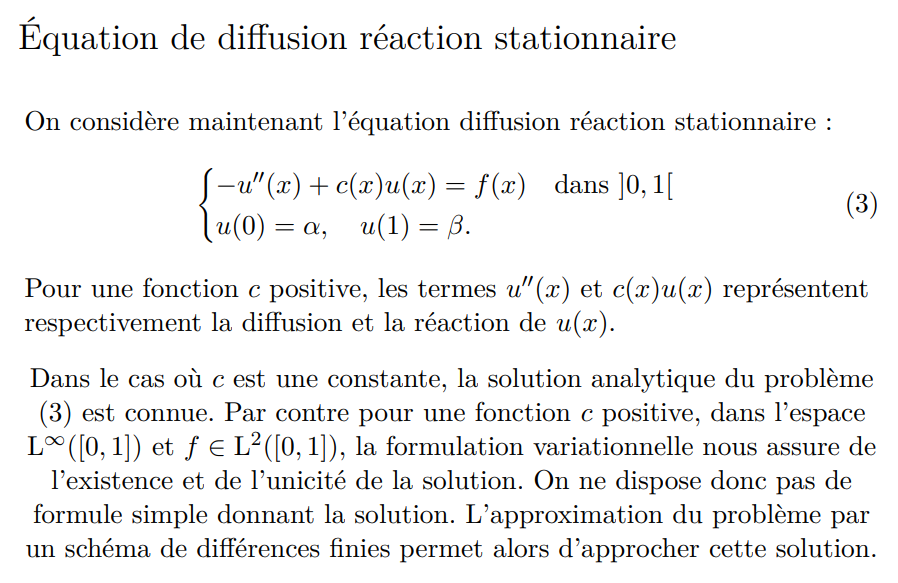

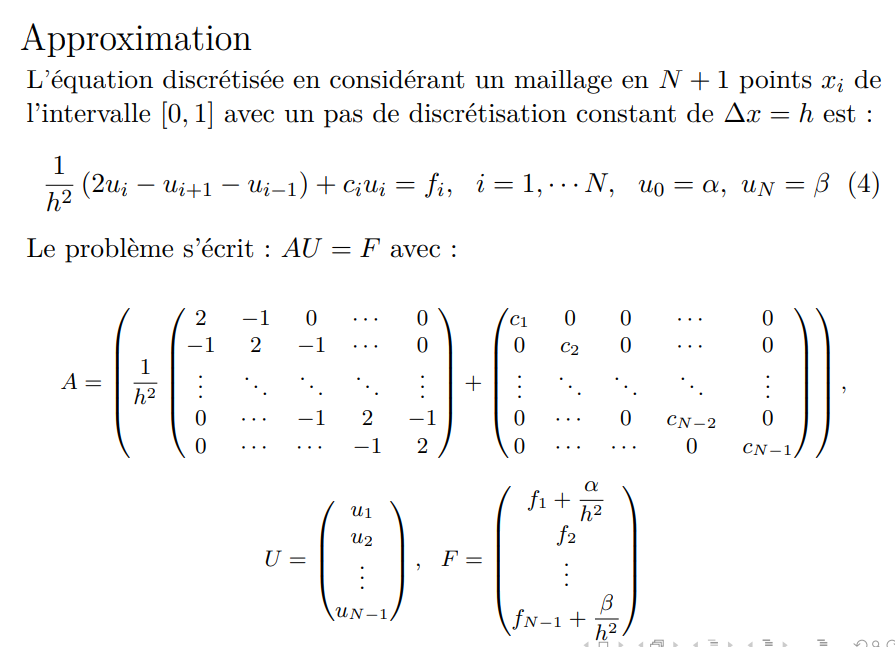

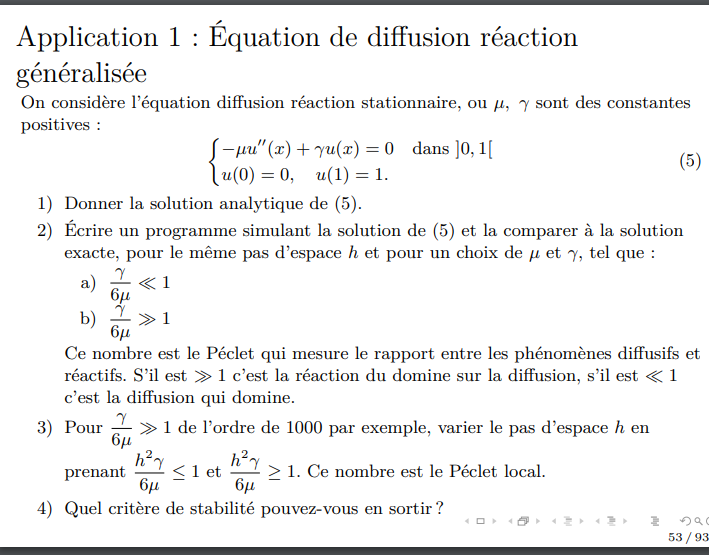

#### 1. La solution analytique de (5) 

In [78]:
from sympy import symbols, Function, Eq, dsolve, sin, cos, exp
from sympy.abc import x 
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
from scipy.linalg import norm

In [79]:
y = Function('y')
u, g = symbols('u g')

In [ ]:
edp = Eq(-u*y(x).diff(x, 2) + g*y(x).diff(x) , 0)
solution_analytique = dsolve(edp, ics={y(0): 0, y(1): 1})
print("Solution particulière de l'EDO avec condition initiale:\n", solution_analytique)
print("\n")
solution_analytique

Solution particulière de l'EDO avec condition initiale:
 Eq(y(x), exp(g*x/u)/(exp(g/u) - 1) - 1/(exp(g/u) - 1))




Eq(y(x), exp(g*x/u)/(exp(g/u) - 1) - 1/(exp(g/u) - 1))

#### 2.Simulation de la solution de (5) 

a. $$ \frac{g}{6u} \ll 1$$ 

In [69]:
gamma = g = 0.01
mu = u = 1
print(gamma / (6 * mu))

0.0016666666666666668


In [81]:
#####################CONSTANTES##################
NX = 10 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas d'espace h
g = 0.01
u = 1
alpha = 0
beta = 1
# gamma / 6 * mu = 0.00166666666 << 1


In [82]:
#####################FONCTIONS##################
# DEFINITION DE LA FONCTION SOURCE F
def func1(x):  
    return 0
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2 ( x ):
    return (
        np.exp(g*x/u)/(np.exp(g/u) - 1) - 1/(np.exp(g/u) - 1)
         )
Uex = np.vectorize ( func2 )


C:\Users\User\AppData\Local\Temp\ipykernel_23664\2086387138.py:23: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  Uint = spsolve(A , F )


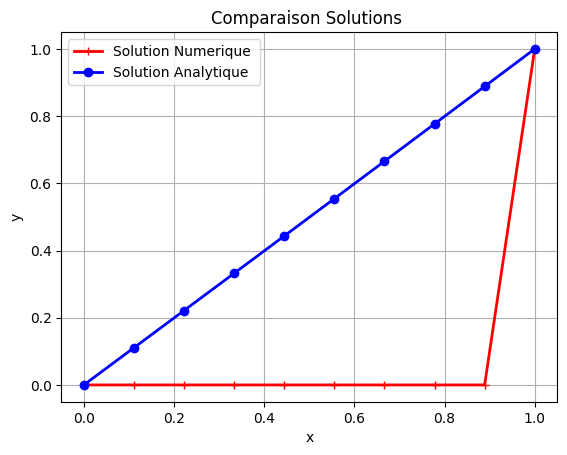

In [83]:
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return ( U )
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
# ax.set_xlim ([0 , 1])
# ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()

########################"Avertissement"############################
# C:\Users\User\AppData\Local\Temp\ipykernel_15460\850092065.py:17: 
# SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
# signifie que la fonction spsolve de scipy.sparse.linalg nécessite que la matrice A
# soit au format CSC (Compressed Sparse Column) ou CSR (Compressed Sparse Row) pour des 
# raisons d'efficacité. 


#### Changement du format de la matrice A

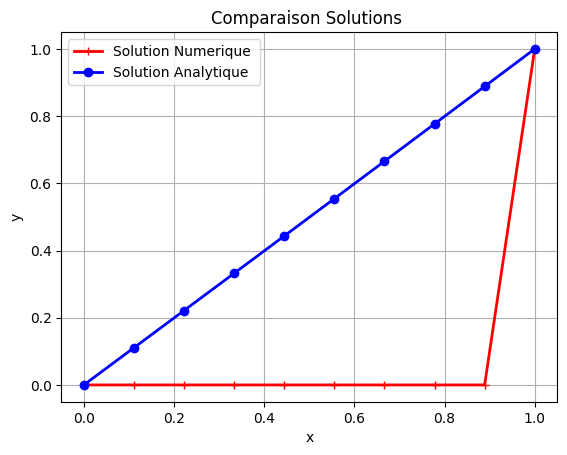

In [84]:
from scipy.sparse import csc_matrix, csr_matrix
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    ########################## "format CSC" ##############################
    A = csc_matrix(A)
    # A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return ( U )
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
# ax.set_xlim ([0 , 1])
# ax.set_ylim ([0 , 0.20])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()

b. $$ \frac{g}{6u} \gg 1$$

In [29]:
gamma = g = 1
mu = u = 0.01
print(gamma / (6 * mu))

16.666666666666668


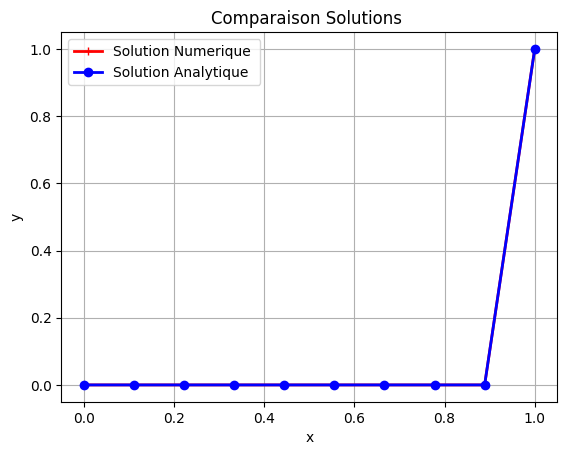

In [87]:
#####################CONSTANTES##################
NX = 10 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas d'espace
gamma = g = 1
mu = u = 0.01
alpha = 0
beta = 1
# gamma / 6 * mu = 16.666666666666668  >> 1
# #####################FONCTIONS##################
def func1(x):  
    return 0
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2 ( x ):
    return (
        np.exp(g*x/u)/(np.exp(g/u) - 1) - 1/(np.exp(g/u) - 1)
    )
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    ########################## "format CSC" ##############################
    # A = csc_matrix(A)
    A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return (U)
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
# ax.set_xlim ([0 , 1])
# ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()

#### 3. Pour $$ \frac{g}{6u} \gg 1 $$ de l'ordre 1000, 
####  Variation du pas d'espace h en prenant :
$$ \frac{h^2 \cdot g}{6 \cdot u} \leq 1 $$ 
$$ \frac{h^2 \cdot g}{6 \cdot u} \geq 1 $$


In [52]:
#################################" h²g / 6u <= 1 "##############################
import math
g = 10
u = 0.01
h = math.sqrt(6 * u / g)
print("h =", h) # h = 0.2449489742783178
h = dx = 1/( NX -1) # Pas d'espace
NX = (1 / h) + 1 
print("NX = ", NX)
print("((h**2) * g) /(6*u) = ", ((h**2) * g) /(6*u), " <= 1") # ((h**2) * g) /(6*u) = 0.08503401360544217 <= 1


h = 0.07745966692414834
NX =  17.0
((h**2) * g) /(6*u) =  0.6510416666666667  <= 1


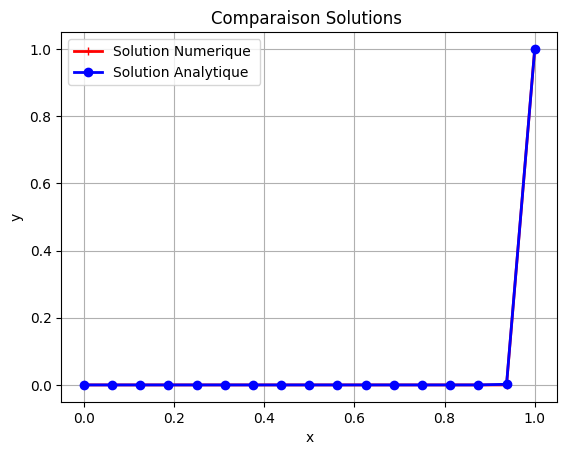

In [ ]:
#####################CONSTANTES##################
NX = 17 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas d'espace
gamma = g = 1
mu = u = 0.01
alpha = 0
beta = 1
# #####################FONCTIONS##################
def func1(x):  
    return 0
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2 ( x ):
    return (        np.exp(g*x/u)/(np.exp(g/u) - 1) - 1/(np.exp(g/u) - 1)

    )
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    ########################## "format CSC" ##############################
    # A = csc_matrix(A)
    A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return (U)
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
# ax.set_xlim ([0 , 1])
# ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()


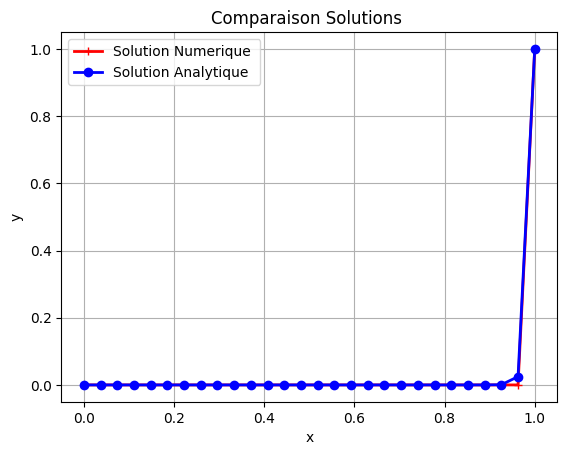

In [56]:
#####################CONSTANTES##################
NX = 28 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas d'espace
gamma = g = 1
mu = u = 0.01
alpha = 0
beta = 1
# gamma / 6 * mu = 600 >> 1
# #####################FONCTIONS##################
# Fonction linéaire : une source qui varie linéairement avec x.
def func1(x):  
    return 0
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2 ( x ):
    return (        np.exp(g*x/u)/(np.exp(g/u) - 1) - 1/(np.exp(g/u) - 1)

    )
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    ########################## "format CSC" ##############################
    # A = csc_matrix(A)
    A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return (U)
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
# ax.set_xlim ([0 , 1])
# ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()


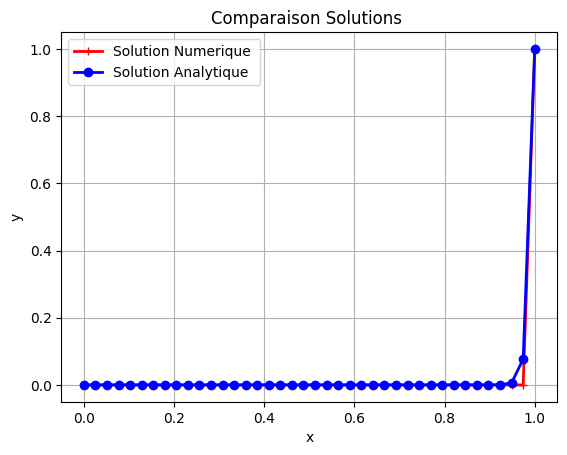

In [57]:
#####################CONSTANTES##################
NX = 40 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas d'espace
gamma = g = 1
mu = u = 0.01
alpha = 0
beta = 1
# gamma / 6 * mu = 600 >> 1
# #####################FONCTIONS##################
# Fonction linéaire : une source qui varie linéairement avec x.
def func1(x):  
    return 0
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2 ( x ):
    return (        np.exp(g*x/u)/(np.exp(g/u) - 1) - 1/(np.exp(g/u) - 1)

    )
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    ########################## "format CSC" ##############################
    # A = csc_matrix(A)
    A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return (U)
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
# ax.set_xlim ([0 , 1])
# ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()


In [88]:
###########################" h²g / 6u >= 1"#########################
import math
g = 1
u = 0.001
h = math.sqrt(6 * u / g)
print("h =", h) # h = 0.2449489742783178
h = dx = 1/( NX -1) # Pas d'espace
NX = (1 / h) + 1 
print("NX = ", NX)
print("((h**2) * g) /(6*u) = ", ((h**2) * g) /(6*u), " >= 1") # ((h**2) * g) /(6*u) = 0.08503401360544217 >= 1


h = 0.024494897427831782
NX =  10.0
((h**2) * g) /(6*u) =  20.576131687242796  >= 1


C:\Users\User\AppData\Local\Temp\ipykernel_23664\833240097.py:19: RuntimeWarning: overflow encountered in exp
  np.exp(g*x/u)/(np.exp(g/u) - 1) - 1/(np.exp(g/u) - 1)
C:\Users\User\AppData\Local\Temp\ipykernel_23664\833240097.py:19: RuntimeWarning: invalid value encountered in scalar divide
  np.exp(g*x/u)/(np.exp(g/u) - 1) - 1/(np.exp(g/u) - 1)


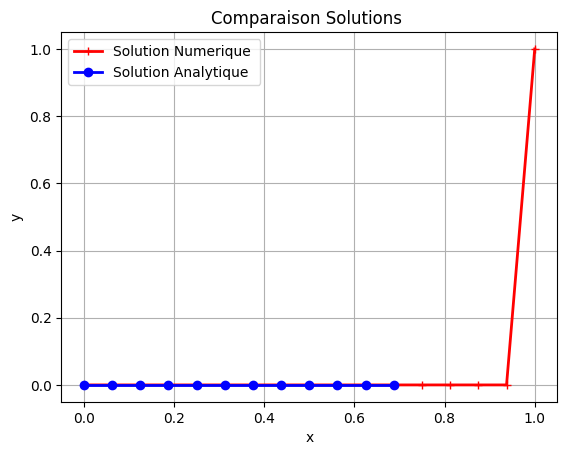

In [ ]:
#####################CONSTANTES##################
NX = 17 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas d'espace
gamma = g = 1
mu = u = 0.001
alpha = 0
beta = 1
# #####################FONCTIONS##################
def func1(x):  
    return 0
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2 ( x ):
    return (        np.exp(g*x/u)/(np.exp(g/u) - 1) - 1/(np.exp(g/u) - 1)

    )
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    ########################## "format CSC" ##############################
    # A = csc_matrix(A)
    A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return (U)
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
# ax.set_xlim ([0 , 1])
# ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()


C:\Users\User\AppData\Local\Temp\ipykernel_23664\833240097.py:19: RuntimeWarning: overflow encountered in exp
  np.exp(g*x/u)/(np.exp(g/u) - 1) - 1/(np.exp(g/u) - 1)
C:\Users\User\AppData\Local\Temp\ipykernel_23664\833240097.py:19: RuntimeWarning: invalid value encountered in scalar divide
  np.exp(g*x/u)/(np.exp(g/u) - 1) - 1/(np.exp(g/u) - 1)


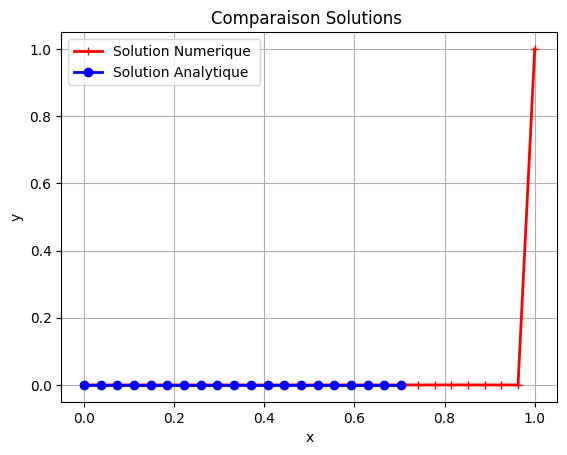

In [61]:
#####################CONSTANTES##################
NX = 28 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas d'espace
gamma = g = 1
mu = u = 0.001
alpha = 0
beta = 1
# gamma / 6 * mu = 600 >> 1
# #####################FONCTIONS##################
# Fonction linéaire : une source qui varie linéairement avec x.
def func1(x):  
    return 0
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2 ( x ):
    return (        np.exp(g*x/u)/(np.exp(g/u) - 1) - 1/(np.exp(g/u) - 1)

    )
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    ########################## "format CSC" ##############################
    # A = csc_matrix(A)
    A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return (U)
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
# ax.set_xlim ([0 , 1])
# ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()


C:\Users\User\AppData\Local\Temp\ipykernel_23664\833240097.py:19: RuntimeWarning: overflow encountered in exp
  np.exp(g*x/u)/(np.exp(g/u) - 1) - 1/(np.exp(g/u) - 1)
C:\Users\User\AppData\Local\Temp\ipykernel_23664\833240097.py:19: RuntimeWarning: invalid value encountered in scalar divide
  np.exp(g*x/u)/(np.exp(g/u) - 1) - 1/(np.exp(g/u) - 1)


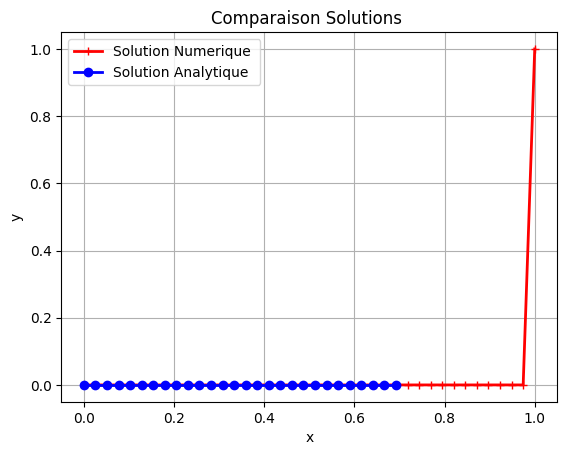

In [62]:
#####################CONSTANTES##################
NX = 40 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas d'espace
gamma = g = 1
mu = u = 0.001
alpha = 0
beta = 1
# gamma / 6 * mu = 600 >> 1
# #####################FONCTIONS##################
# Fonction linéaire : une source qui varie linéairement avec x.
def func1(x):  
    return 0
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2 ( x ):
    return (        np.exp(g*x/u)/(np.exp(g/u) - 1) - 1/(np.exp(g/u) - 1)

    )
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    ########################## "format CSC" ##############################
    # A = csc_matrix(A)
    A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return (U)
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
# ax.set_xlim ([0 , 1])
# ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()
